In [1]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
print("OSMnx version:", ox.__version__)
print("NetworkX version:", nx.__version__)

# 같은 자료를 반복해서 내려받지 않도록 캐시 사용
ox.settings.use_cache = True

# 다운로드 진행상황 출력
ox.settings.log_console = True

OSMnx version: 2.1.0
NetworkX version: 3.2.1


In [3]:
place_name = "Seongdong-gu, Seoul, South Korea"

G = ox.graph.graph_from_place(
    place_name,
    network_type="walk",
    simplify=True,
    retain_all=False
)

print(type(G))
print("노드 수:", G.number_of_nodes())
print("엣지 수:", G.number_of_edges())
print("좌표계:", G.graph["crs"])

<class 'networkx.classes.multidigraph.MultiDiGraph'>
노드 수: 5586
엣지 수: 15870
좌표계: epsg:4326


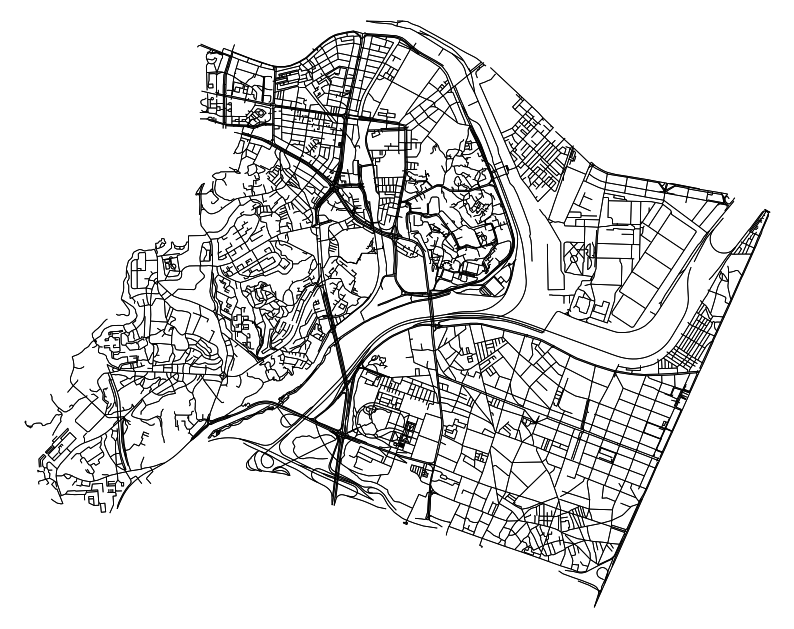

In [14]:
fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="black",
    edge_linewidth=0.6,
    bgcolor="white",
    figsize=(10, 10),
    show=False,
    close=False
)

fig.savefig(
    "seongdong_walk_network_white.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0,
    facecolor="white",
    transparent=False
)

plt.show()

In [12]:
ox.io.save_graphml(G, filepath="seongdong_walk.graphml")

print("저장 완료")

저장 완료


In [6]:
# 보행속도: 1.2 m/s
WALK_SPEED_MPS = 1.2

# 각 엣지의 길이(length, m)를 보행시간(초)으로 변환
for u, v, k, data in G.edges(keys=True, data=True):
    data["walk_time_sec"] = data["length"] / WALK_SPEED_MPS

# 일부 엣지 확인
sample_edge = next(iter(G.edges(keys=True, data=True)))
print(sample_edge)

(287287152, 8495290882, 0, {'osmid': 218655250, 'highway': 'primary', 'name': '고산자로', 'ref': '51', 'oneway': False, 'reversed': True, 'length': 18.496648068074066, 'walk_time_sec': 15.413873390061722})


In [7]:
origin_name = "Wangsimni Station, Seongdong-gu, Seoul, South Korea"
destination_name = "Seoul Forest, Seongdong-gu, Seoul, South Korea"

# 결과는 (위도, 경도) 순서
origin_latlon = ox.geocoder.geocode(origin_name)
destination_latlon = ox.geocoder.geocode(destination_name)

print("출발지 좌표:", origin_latlon)
print("도착지 좌표:", destination_latlon)

출발지 좌표: (37.5611294, 127.0354654)
도착지 좌표: (37.5435916, 127.0447397)


In [8]:
origin_lat, origin_lon = origin_latlon
destination_lat, destination_lon = destination_latlon

# nearest_nodes에서는 X=경도, Y=위도 순서
origin_node, origin_snap_dist = ox.distance.nearest_nodes(
    G,
    X=origin_lon,
    Y=origin_lat,
    return_dist=True
)

destination_node, destination_snap_dist = ox.distance.nearest_nodes(
    G,
    X=destination_lon,
    Y=destination_lat,
    return_dist=True
)

print("출발 노드:", origin_node)
print("도착 노드:", destination_node)
print(f"출발지 스냅 거리: {origin_snap_dist:.1f} m")
print(f"도착지 스냅 거리: {destination_snap_dist:.1f} m")

출발 노드: 10182586006
도착 노드: 9081846792
출발지 스냅 거리: 6.6 m
도착지 스냅 거리: 14.9 m


In [9]:
route = ox.routing.shortest_path(
    G,
    origin_node,
    destination_node,
    weight="walk_time_sec"
)

if route is None:
    raise RuntimeError("두 지점 사이의 보행경로를 찾지 못했습니다.")

print("경로에 포함된 노드 수:", len(route))

경로에 포함된 노드 수: 37


In [10]:
route_edges = ox.routing.route_to_gdf(
    G,
    route,
    weight="walk_time_sec"
)

route_distance_m = route_edges["length"].sum()
route_time_sec = route_edges["walk_time_sec"].sum()

print(f"총 보행거리: {route_distance_m:.1f} m")
print(f"총 보행시간: {route_time_sec / 60:.2f} 분")

총 보행거리: 2372.4 m
총 보행시간: 32.95 분


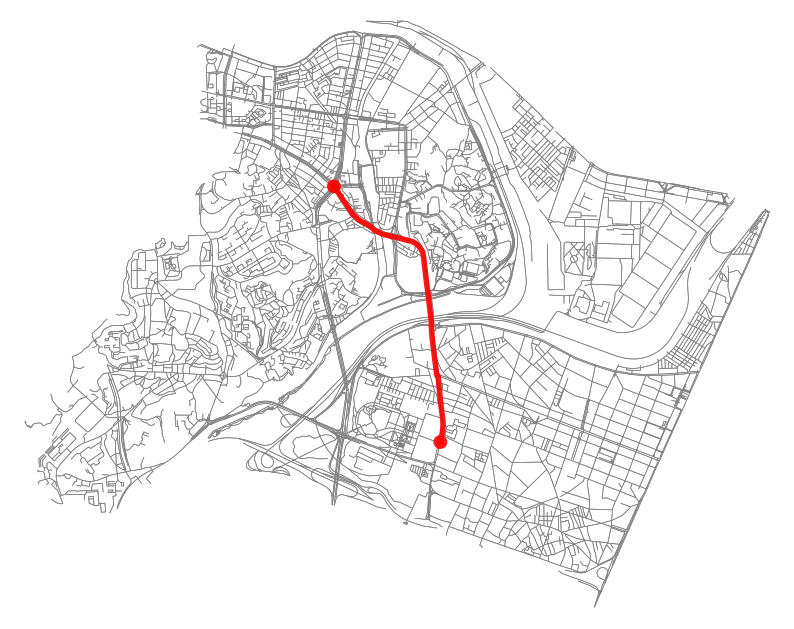

In [11]:
fig, ax = ox.plot.plot_graph_route(
    G,
    route,
    route_color="red",
    route_linewidth=4,
    route_alpha=0.9,
    orig_dest_size=100,
    node_size=0,
    edge_color="gray",
    edge_linewidth=0.5,
    bgcolor="white",
    figsize=(10, 10)
)

In [14]:
WALK_SPEED_MPS = 1.2

# walk_time_sec가 없는 경우 다시 생성
if not all(
    "walk_time_sec" in data
    for _, _, _, data in G.edges(keys=True, data=True)
):
    for u, v, k, data in G.edges(keys=True, data=True):
        data["walk_time_sec"] = data["length"] / WALK_SPEED_MPS

# 성동구 지역에 적합한 투영좌표계로 자동 변환
G_proj = ox.projection.project_graph(G)

print("기존 좌표계:", G.graph["crs"])
print("투영 후 좌표계:", G_proj.graph["crs"])

기존 좌표계: epsg:4326
투영 후 좌표계: EPSG:32652
